# Zond Piek

Data ingelezen: 96 tijdstappen (24 uur, dt = 0.25 h)
Prijs range: 0.0023 .. 0.0592 EUR/kWh
Buitentemperatuur range: 5.0 .. 9.7 degC

Koelvraagprofiel Q_demand (constante proceskoeling):
  Q_demand :  45.0 kW (constant over de hele dag)

Temperatuurafhankelijke COP gedefinieerd:
  Temperatuurpunten: [0, 5, 10, 15, 20, 25, 30] degC
  COP-waarden:       [4.5, 4.3, 4.0, 3.7, 3.4, 3.1, 2.8]
  COP range (actueel): 4.02 .. 4.30
  Gemiddelde COP:    4.14

Fysische omrekening buffervat: 6.98 kWh/m3 (theoretisch)
Gebruikte praktische omrekening: 8.0 kWh/m3

Totale kosten ZONDER optimalisatie (referentie): 90.91 EUR
  V =   1.0 m3  ->  E_max =   8.0 kWh  |  kosten =   90.77 EUR  |  besparing =  0.13 EUR ( 0.1 %)  | status=optimal
  V =   2.5 m3  ->  E_max =  20.0 kWh  |  kosten =   90.58 EUR  |  besparing =  0.33 EUR ( 0.4 %)  | status=optimal
  V =   5.0 m3  ->  E_max =  40.0 kWh  |  kosten =   90.25 EUR  |  besparing =  0.66 EUR ( 0.7 %)  | status=optimal
  V =   7.5 m3  ->  E_max =  60.0 kWh  

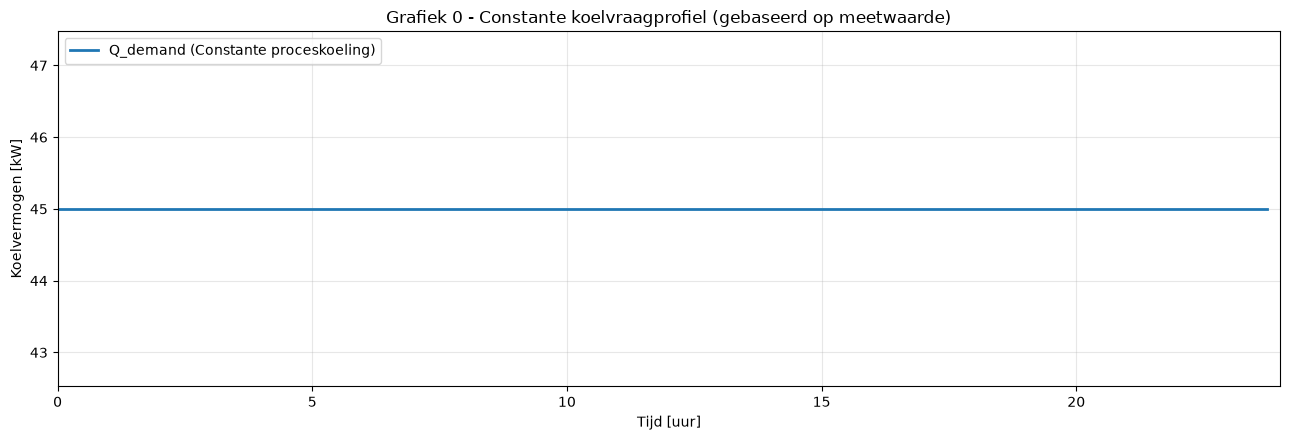

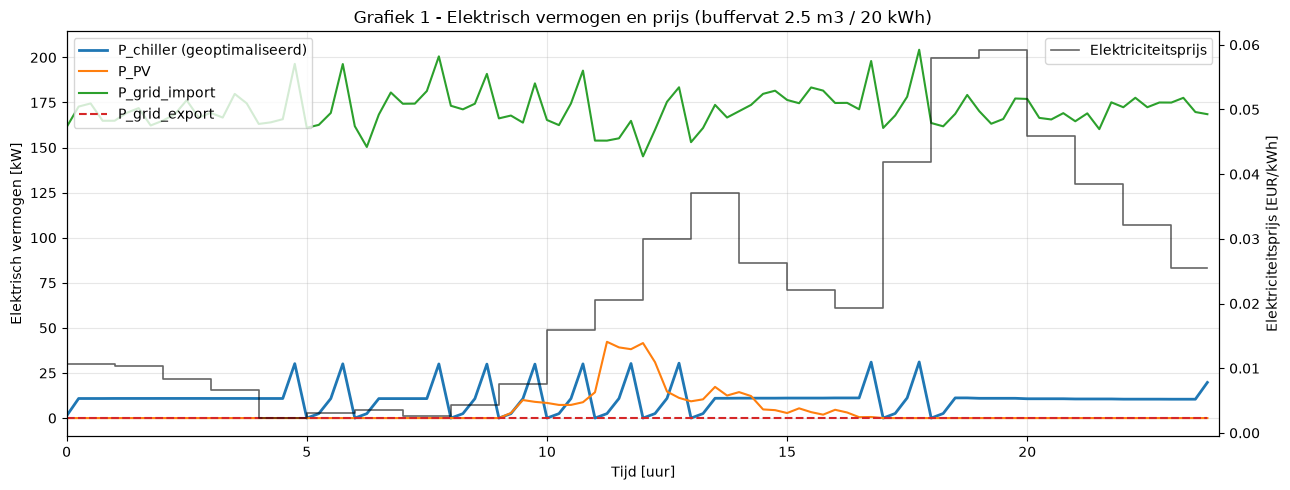

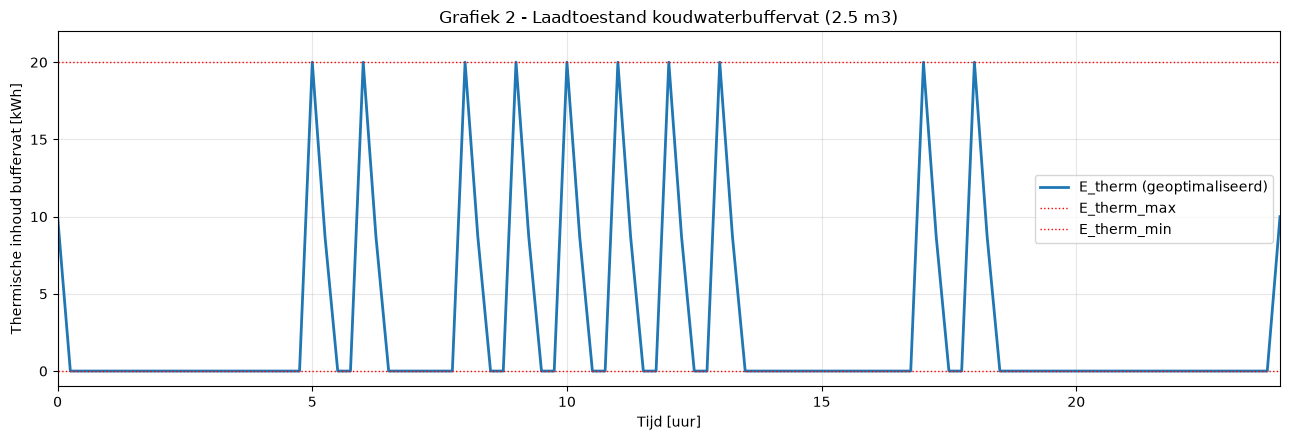

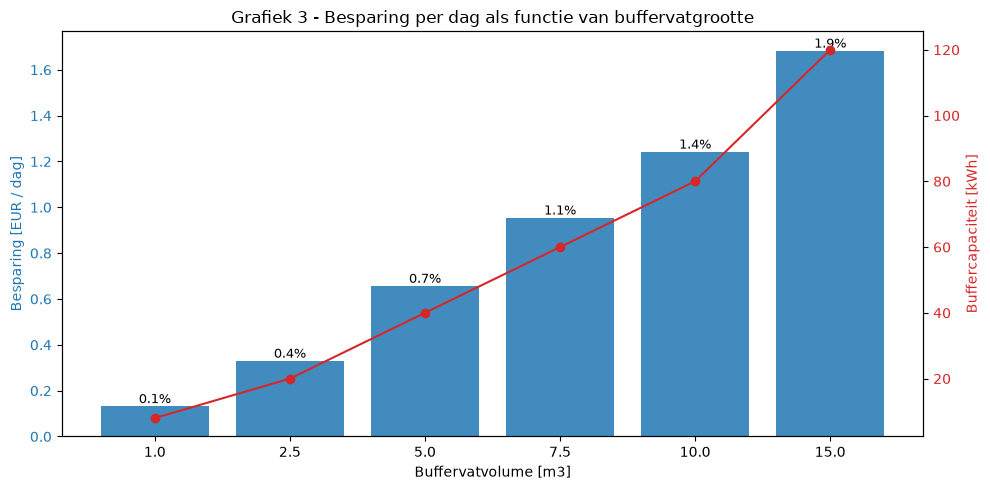

In [58]:
"""
Optimalisatie van chiller-aansturing met koudwaterbuffervat (24 uur, kwartierresolutie)
1 Chiller, constante proceskoeling (dag en nacht gelijk).
=========================================================================================

Doel:
    Minimaliseer de netto elektriciteitskosten van een fabriek door het elektrisch
    vermogen van een chiller (met koudwaterbuffervat) slim te sturen, rekening
    houdend met de elektriciteitsprijs, PV-productie en niet-flexibele belasting.

Auteur: Energiemanagement / CVXPY optimalisatie
"""

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =============================================================================
# 1. DATA INLEZEN EN VOORBEREIDEN
# =============================================================================

CSV_PATH = "plant1.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

# Eerste 24 uur = eerste 96 kwartieren (96 * 15 min = 24 h)
N_STEPS = 96
df = df.iloc[:N_STEPS].reset_index(drop=True)

dt = 0.25  # uur, tijdstap

# Prijs staat in EUR/MWh in plant1.csv -> omrekenen naar EUR/kWh
price = df["price"].values / 1000.0  # [EUR/kWh]
P_pv = df["pv_production"].values  # [kW]
P_inflex = df["inflex_load"].values  # [kW]
T_outdoor = df["outdoor_temperature"].values  # [degC]

time_h = np.arange(N_STEPS) * dt  # tijdas in uren (0 .. 23.75)

print(f"Data ingelezen: {N_STEPS} tijdstappen (24 uur, dt = {dt} h)")
print(f"Prijs range: {price.min():.4f} .. {price.max():.4f} EUR/kWh")
print(f"Buitentemperatuur range: {T_outdoor.min():.1f} .. {T_outdoor.max():.1f} degC")

# =============================================================================
# 2. KOELVRAAGPROFIEL (Constante proceskoeling op basis van meting)
# =============================================================================

# Jouw meting: 10.15 kW elektrisch vermogen.
# Bij een typische COP van ~4.4 komt dit neer op een thermische last van ~45 kW.
# Omdat het proces dag en nacht hetzelfde is, gebruiken we een constante waarde.
Q_process_constant = 45.0  # kW thermisch

Q_process = np.full(N_STEPS, Q_process_constant)
Q_demand = Q_process

print(f"\nKoelvraagprofiel Q_demand (constante proceskoeling):")
print(f"  Q_demand : {Q_demand[0]:5.1f} kW (constant over de hele dag)")

# =============================================================================
# 3. VASTE PARAMETERS & TEMPERATUURAFHANKELIJKE COP
# =============================================================================

# --- Chiller (1 chiller, 250 kW elektrisch maximum) ---
P_max_chiller = 250.0  # kW elektrisch, maximaal vermogen chiller

# --- DATASHEET: Temperatuurafhankelijke COP ---
temp_points = [0, 5, 10, 15, 20, 25, 30]  # [degC], buitentemperatuur
cop_points = [4.5, 4.3, 4.0, 3.7, 3.4, 3.1, 2.8]  # [-], corresponderende COP


def calculate_cop_array(T_outdoor_array, temp_points, cop_points):
  """Bepaalt de COP voor elke buitentemperatuur via lineaire interpolatie."""
  COP_t = np.interp(T_outdoor_array, temp_points, cop_points)
  return COP_t


# Bereken COP-array gebaseerd op actuele buitentemperaturen
COP_t = calculate_cop_array(T_outdoor, temp_points, cop_points)

print(f"\nTemperatuurafhankelijke COP gedefinieerd:")
print(f"  Temperatuurpunten: {temp_points} degC")
print(f"  COP-waarden:       {cop_points}")
print(f"  COP range (actueel): {COP_t.min():.2f} .. {COP_t.max():.2f}")
print(f"  Gemiddelde COP:    {COP_t.mean():.2f}")

# --- Buffervat: thermofysische omrekening volume -> energie-inhoud ---
RHO_WATER = 1000.0  # kg/m3
CP_WATER = 4.186  # kJ/(kg.K)
DELTA_T = 6.0  # K (12 degC - 6 degC)
KWH_PER_M3_PHYSICAL = (
    RHO_WATER * CP_WATER * DELTA_T / 3600.0
)  # kJ -> kWh
KWH_PER_M3 = 8.0  # kWh/m3 (praktische afgeronde waarde)

print(
    f"\nFysische omrekening buffervat:"
    f" {KWH_PER_M3_PHYSICAL:.2f} kWh/m3 (theoretisch)"
)
print(f"Gebruikte praktische omrekening: {KWH_PER_M3:.1f} kWh/m3")

eta_loss = 0.998  # stilstandsverlies-efficiëntie per tijdstap (~0.8%/uur)
E_therm_min = 0.0  # kWh, minimale thermische inhoud (ondergrens buffer)

# =============================================================================
# 4. OPTIMALISATIEFUNCTIE (herbruikbaar per buffergrootte)
# =============================================================================


def solve_chiller_schedule(E_therm_max, COP_array, E_therm_0=None):
  """Lost het optimalisatieprobleem op voor een gegeven buffervatcapaciteit."""
  if E_therm_0 is None:
    E_therm_0 = 0.5 * E_therm_max

  P_chiller = cp.Variable(N_STEPS, nonneg=True)
  P_grid_import = cp.Variable(N_STEPS, nonneg=True)
  P_grid_export = cp.Variable(N_STEPS, nonneg=True)
  E_therm = cp.Variable(N_STEPS + 1)

  # Bereken Q_chiller met temperatuurafhankelijke COP
  Q_chiller = cp.multiply(COP_array, P_chiller)

  constraints = [
      P_chiller <= P_max_chiller,
      E_therm[0] == E_therm_0,
      E_therm >= E_therm_min,
      E_therm <= E_therm_max,
      E_therm[N_STEPS] == E_therm_0,  # RANDVOORWAARDE EINDE DAG
      P_pv + P_grid_import == P_chiller + P_inflex + P_grid_export,
  ]
  for t in range(N_STEPS):
    constraints += [
        E_therm[t + 1]
        == eta_loss * E_therm[t] + (Q_chiller[t] - Q_demand[t]) * dt
    ]

  objective = cp.Minimize(
      cp.sum(cp.multiply(P_grid_import - P_grid_export, price) * dt)
  )
  problem = cp.Problem(objective, constraints)
  cost_opt = problem.solve(solver=cp.HIGHS)

  return {
      "status": problem.status,
      "cost": cost_opt,
      "E_therm_max": E_therm_max,
      "E_therm_0": E_therm_0,
      "P_chiller": P_chiller.value,
      "P_grid_import": P_grid_import.value,
      "P_grid_export": P_grid_export.value,
      "E_therm": E_therm.value,
  }


# =============================================================================
# 5. REFERENTIESCENARIO (chiller volgt Q_demand direct, geen sturing)
# =============================================================================

P_chiller_ref = np.clip(Q_demand / COP_t, 0, P_max_chiller)
net_ref = P_chiller_ref + P_inflex - P_pv
P_grid_import_ref = np.clip(net_ref, 0, None)
P_grid_export_ref = np.clip(-net_ref, 0, None)
cost_ref = np.sum((P_grid_import_ref - P_grid_export_ref) * price * dt)

print(f"\nTotale kosten ZONDER optimalisatie (referentie): {cost_ref:.2f} EUR")

# =============================================================================
# 6. BUFFERVATGROOTTE LATEN VARIËREN
# =============================================================================

buffer_volumes_m3 = [1.0, 2.5, 5.0, 7.5, 10.0, 15.0]  # m3
buffer_results = []

for V in buffer_volumes_m3:
  E_max = V * KWH_PER_M3
  res = solve_chiller_schedule(E_therm_max=E_max, COP_array=COP_t)
  saving_eur = cost_ref - res["cost"]
  saving_pct = 100 * saving_eur / cost_ref if cost_ref != 0 else np.nan
  buffer_results.append({
      "volume_m3": V,
      "E_therm_max_kWh": E_max,
      "cost_opt": res["cost"],
      "saving_eur": saving_eur,
      "saving_pct": saving_pct,
      "solution": res,
  })
  print(
      f"  V = {V:5.1f} m3  ->  E_max = {E_max:5.1f} kWh  |  "
      f"kosten = {res['cost']:7.2f} EUR  |  besparing = {saving_eur:5.2f} EUR "
      f"({saving_pct:4.1f} %)  | status={res['status']}"
  )

results_df = pd.DataFrame([
    {
        "Volume [m3]": r["volume_m3"],
        "E_therm_max [kWh]": r["E_therm_max_kWh"],
        "Kosten geoptimaliseerd [EUR]": r["cost_opt"],
        "Besparing [EUR]": r["saving_eur"],
        "Besparing [%]": r["saving_pct"],
    }
    for r in buffer_results
])

print("\n" + "=" * 70)
print("RESULTATENOVERZICHT PER BUFFERVATGROOTTE")
print("=" * 70)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:8.2f}"))
print("=" * 70)
print(f"Referentie (geen sturing) : {cost_ref:.2f} EUR")

representative = next(r for r in buffer_results if r["volume_m3"] == 2.5)
sol = representative["solution"]

# =============================================================================
# 7. GRAFIEKEN
# =============================================================================

# --- Grafiek 0: constante koelvraagprofiel ---
fig0, ax0 = plt.subplots(figsize=(13, 4.5))
ax0.plot(
    time_h,
    Q_demand,
    color="tab:blue",
    linewidth=2,
    label="Q_demand (Constante proceskoeling)",
)
ax0.set_xlabel("Tijd [uur]")
ax0.set_ylabel("Koelvermogen [kW]")
ax0.set_xlim(0, 24)
ax0.set_title(
    "Grafiek 0 - Constante koelvraagprofiel (gebaseerd op meetwaarde)"
)
ax0.legend(loc="upper left")
ax0.grid(alpha=0.3)
fig0.tight_layout()

# --- Grafiek 1: elektrisch vermogen + prijs (representatieve case: 2.5 m3) ---
fig1, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(
    time_h,
    sol["P_chiller"],
    label="P_chiller (geoptimaliseerd)",
    color="tab:blue",
    linewidth=2,
)
ax1.plot(time_h, P_pv, label="P_PV", color="tab:orange", linewidth=1.5)
ax1.plot(
    time_h,
    sol["P_grid_import"],
    label="P_grid_import",
    color="tab:green",
    linewidth=1.5,
)
ax1.plot(
    time_h,
    sol["P_grid_export"],
    label="P_grid_export",
    color="tab:red",
    linewidth=1.5,
    linestyle="--",
)
ax1.set_xlabel("Tijd [uur]")
ax1.set_ylabel("Elektrisch vermogen [kW]")
ax1.set_xlim(0, 24)
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")

ax1b = ax1.twinx()
ax1b.step(
    time_h,
    price,
    where="post",
    color="black",
    linewidth=1.2,
    alpha=0.6,
    label="Elektriciteitsprijs",
)
ax1b.set_ylabel("Elektriciteitsprijs [EUR/kWh]")
ax1b.legend(loc="upper right")
ax1.set_title(
    f"Grafiek 1 - Elektrisch vermogen en prijs (buffervat 2.5 m3 /"
    f" {representative['E_therm_max_kWh']:.0f} kWh)"
)
fig1.tight_layout()

# --- Grafiek 2: laadtoestand buffervat (representatieve case: 2.5 m3) ---
fig2, ax2 = plt.subplots(figsize=(13, 4.5))
time_h_full = np.arange(N_STEPS + 1) * dt
ax2.plot(
    time_h_full,
    sol["E_therm"],
    label="E_therm (geoptimaliseerd)",
    color="tab:blue",
    linewidth=2,
)
ax2.axhline(
    representative["E_therm_max_kWh"],
    color="red",
    linestyle=":",
    linewidth=1,
    label="E_therm_max",
)
ax2.axhline(
    E_therm_min, color="red", linestyle=":", linewidth=1, label="E_therm_min"
)
ax2.set_xlabel("Tijd [uur]")
ax2.set_ylabel("Thermische inhoud buffervat [kWh]")
ax2.set_xlim(0, 24)
ax2.set_ylim(-1, representative["E_therm_max_kWh"] + 2)
ax2.grid(alpha=0.3)
ax2.legend(loc="best")
ax2.set_title("Grafiek 2 - Laadtoestand koudwaterbuffervat (2.5 m3)")
fig2.tight_layout()

# --- Grafiek 3: besparing als functie van buffervatgrootte ---
fig3, ax3 = plt.subplots(figsize=(10, 5))
volumes = [r["volume_m3"] for r in buffer_results]
savings_eur = [r["saving_eur"] for r in buffer_results]
savings_pct = [r["saving_pct"] for r in buffer_results]

bars = ax3.bar(
    [str(v) for v in volumes], savings_eur, color="tab:blue", alpha=0.85
)
ax3.set_xlabel("Buffervatvolume [m3]")
ax3.set_ylabel("Besparing [EUR / dag]", color="tab:blue")
ax3.tick_params(axis="y", labelcolor="tab:blue")
for bar, pct in zip(bars, savings_pct):
  ax3.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height(),
      f"{pct:.1f}%",
      ha="center",
      va="bottom",
      fontsize=9,
  )

ax3b = ax3.twinx()
E_max_list = [r["E_therm_max_kWh"] for r in buffer_results]
ax3b.plot(
    [str(v) for v in volumes],
    E_max_list,
    color="tab:red",
    marker="o",
    label="E_therm_max [kWh]",
)
ax3b.set_ylabel("Buffercapaciteit [kWh]", color="tab:red")
ax3b.tick_params(axis="y", labelcolor="tab:red")

ax3.set_title("Grafiek 3 - Besparing per dag als functie van buffervatgrootte")
fig3.tight_layout()

plt.show()

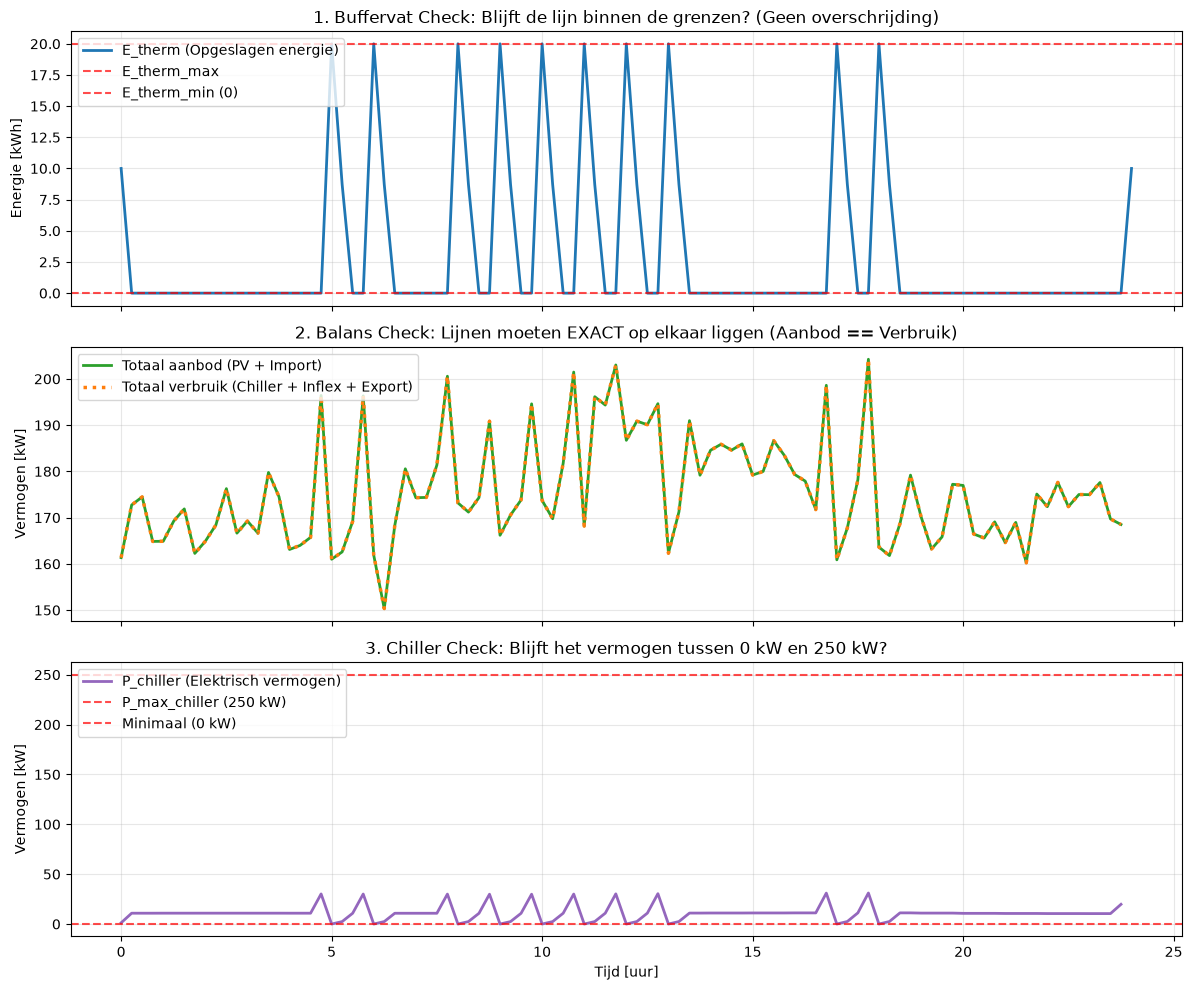

In [59]:
# Voor de representatieve case (2.5 m3) die je onderaan het script hebt opgeslagen:
import matplotlib.pyplot as plt
import numpy as np

def plot_feasibility_checks(sol, time_h, P_pv, P_inflex, E_therm_max, P_max_chiller, dt):
    """
    Genereert 3 subplots om de fysieke haalbaarheid (feasibility) 
    van het optimalisatieresultaat visueel te controleren.
    """
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    
    time_h_full = np.arange(len(sol["E_therm"])) * dt

    # --- 1. BUFFERVAT GRENZEN CHECK ---
    axes[0].plot(time_h_full, sol["E_therm"], label="E_therm (Opgeslagen energie)", color="tab:blue", linewidth=2)
    axes[0].axhline(E_therm_max, color="red", linestyle="--", alpha=0.7, label="E_therm_max")
    axes[0].axhline(0, color="red", linestyle="--", alpha=0.7, label="E_therm_min (0)")
    axes[0].set_ylabel("Energie [kWh]")
    axes[0].set_title("1. Buffervat Check: Blijft de lijn binnen de grenzen? (Geen overschrijding)")
    axes[0].legend(loc="upper left")
    axes[0].grid(alpha=0.3)

    # --- 2. ELEKTRISCHE BALANS CHECK ---
    # Aanbod = P_pv + P_grid_import
    # Vraag   = P_chiller + P_inflex + P_grid_export
    total_supply = P_pv + sol["P_grid_import"]
    total_demand = sol["P_chiller"] + P_inflex + sol["P_grid_export"]
    
    axes[1].plot(time_h, total_supply, label="Totaal aanbod (PV + Import)", color="tab:green", linewidth=2)
    axes[1].plot(time_h, total_demand, label="Totaal verbruik (Chiller + Inflex + Export)", color="tab:orange", linestyle=":", linewidth=2.5)
    axes[1].set_ylabel("Vermogen [kW]")
    axes[1].set_title("2. Balans Check: Lijnen moeten EXACT op elkaar liggen (Aanbod == Verbruik)")
    axes[1].legend(loc="upper left")
    axes[1].grid(alpha=0.3)

    # --- 3. CHILLER VERMOGEN GRENZEN CHECK ---
    axes[2].plot(time_h, sol["P_chiller"], label="P_chiller (Elektrisch vermogen)", color="tab:purple", linewidth=2)
    axes[2].axhline(P_max_chiller, color="red", linestyle="--", alpha=0.7, label="P_max_chiller (250 kW)")
    axes[2].axhline(0, color="red", linestyle="--", alpha=0.7, label="Minimaal (0 kW)")
    axes[2].set_xlabel("Tijd [uur]")
    axes[2].set_ylabel("Vermogen [kW]")
    axes[2].set_title("3. Chiller Check: Blijft het vermogen tussen 0 kW en 250 kW?")
    axes[2].legend(loc="upper left")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_feasibility_checks(sol, time_h, P_pv, P_inflex, representative["E_therm_max_kWh"], P_max_chiller, dt)

# Voorbeeld van hoe je dit aanroept in je script (voor de 2.5 m3 case):
# plot_feasibility_checks(sol, time_h, P_pv, P_inflex, representative["E_therm_max_kWh"], P_max_chiller, dt)

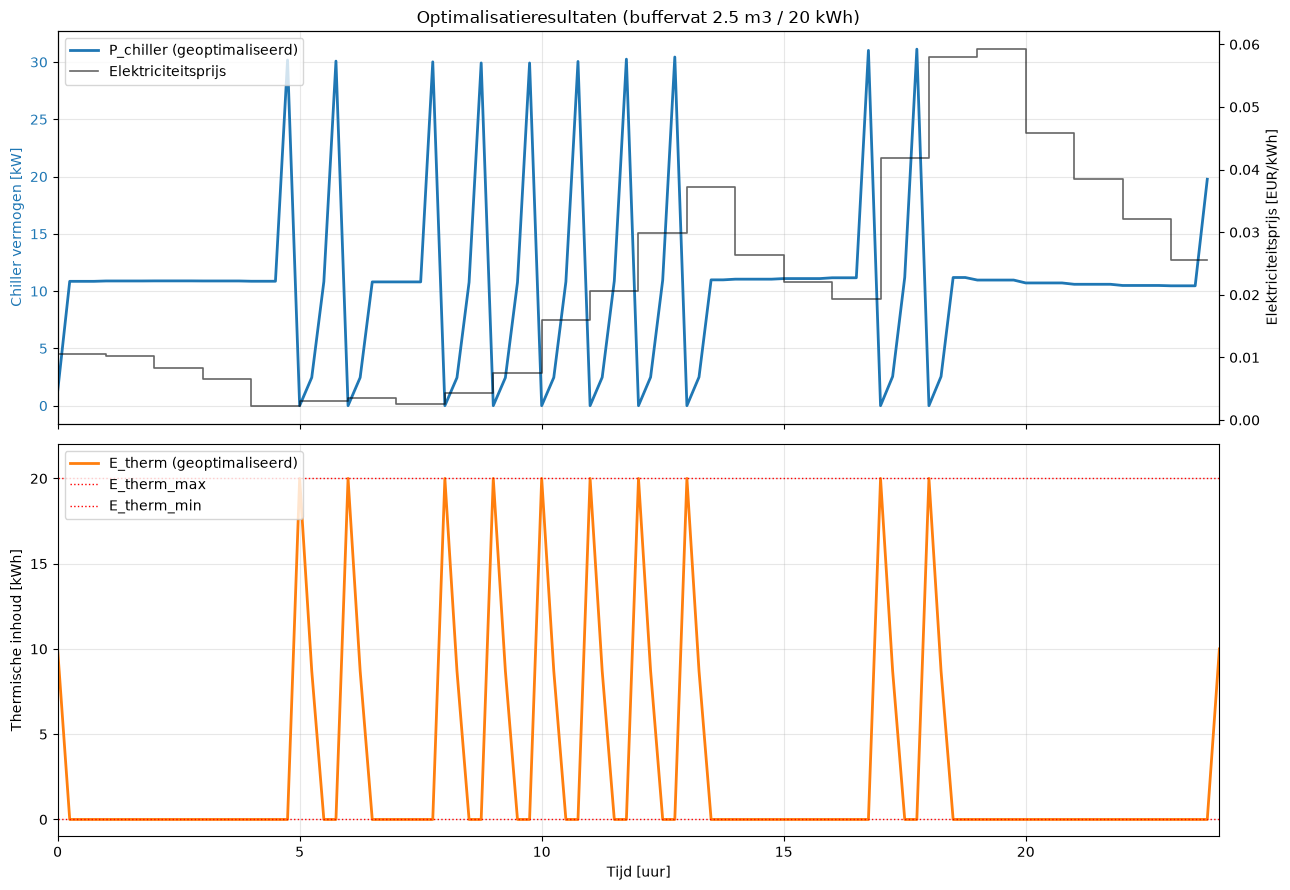

In [64]:
# =============================================================================
# 7. GECOMBINEERDE GRAFIEK (Boven: Vermogen & Prijs, Onder: E_therm)
# =============================================================================

fig, (ax_top, ax_bottom) = plt.subplots(
    nrows=2, ncols=1, figsize=(13, 9), sharex=True
)

# --- Bovenste plot: Vermogen chiller en elektriciteitsprijs ---
ax_top.plot(
    time_h,
    sol["P_chiller"],
    label="P_chiller (geoptimaliseerd)",
    color="tab:blue",
    linewidth=2,
)
ax_top.set_ylabel("Chiller vermogen [kW]", color="tab:blue")
ax_top.tick_params(axis="y", labelcolor="tab:blue")
ax_top.set_xlim(0, 24)
ax_top.grid(alpha=0.3)

# Tweede Y-as voor elektriciteitsprijs
ax_top_price = ax_top.twinx()
ax_top_price.step(
    time_h,
    price,
    where="post",
    color="black",
    linewidth=1.2,
    alpha=0.6,
    label="Elektriciteitsprijs",
)
ax_top_price.set_ylabel("Elektriciteitsprijs [EUR/kWh]", color="black")
ax_top_price.tick_params(axis="y", labelcolor="black")

# Gecombineerde legenda voor bovenste plot
lines_top, labels_top = ax_top.get_legend_handles_labels()
lines_price, labels_price = ax_top_price.get_legend_handles_labels()
ax_top.legend(
    lines_top + lines_price, labels_top + labels_price, loc="upper left"
)
ax_top.set_title(
    f"Optimalisatieresultaten (buffervat 2.5 m3 /"
    f" {representative['E_therm_max_kWh']:.0f} kWh)"
)

# --- Onderste plot: E_therm (laadtoestand buffervat) ---
time_h_full = np.arange(N_STEPS + 1) * dt
ax_bottom.plot(
    time_h_full,
    sol["E_therm"],
    label="E_therm (geoptimaliseerd)",
    color="tab:orange",
    linewidth=2,
)
ax_bottom.axhline(
    representative["E_therm_max_kWh"],
    color="red",
    linestyle=":",
    linewidth=1,
    label="E_therm_max",
)
ax_bottom.axhline(
    E_therm_min, color="red", linestyle=":", linewidth=1, label="E_therm_min"
)
ax_bottom.set_xlabel("Tijd [uur]")
ax_bottom.set_ylabel("Thermische inhoud [kWh]")
ax_bottom.set_xlim(0, 24)
ax_bottom.set_ylim(-1, representative["E_therm_max_kWh"] + 2)
ax_bottom.grid(alpha=0.3)
ax_bottom.legend(loc="upper left")

fig.tight_layout()
plt.show()

# Met piek

Capaciteitstarief ingesteld (dagelijks equivalent):
  Piek tarief: 0.1409 EUR/kW/dag
  Access power: 2.5 kW

Optimalisatie status: optimal
Totale kosten (inclusief capaciteitstarief): 115.65 EUR
Maximale netafname piek vandaag: 176.78 kW


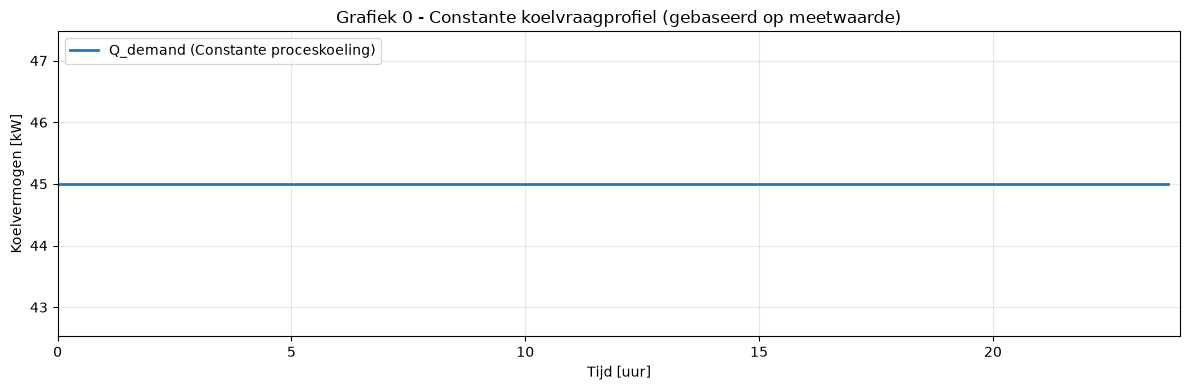

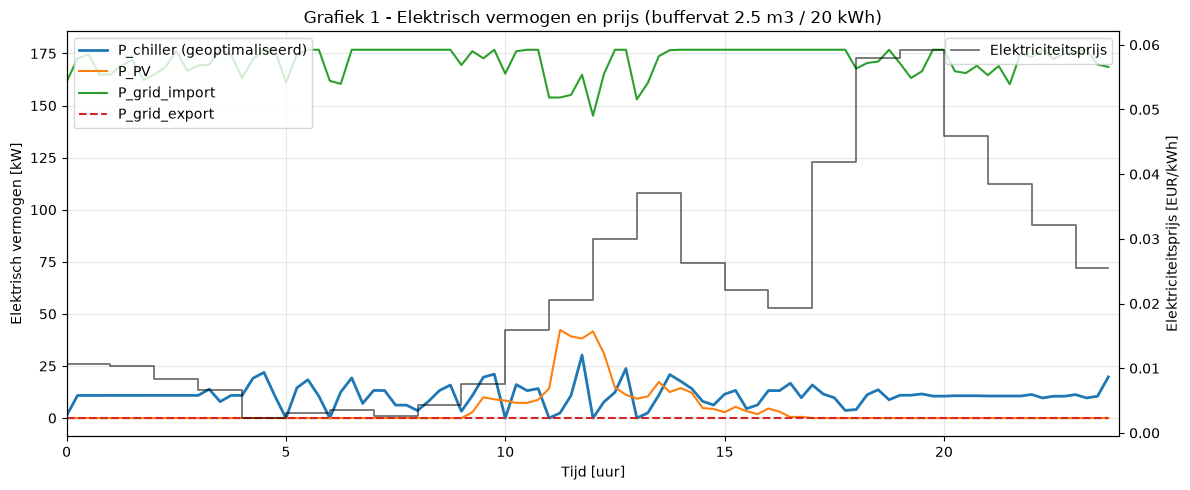

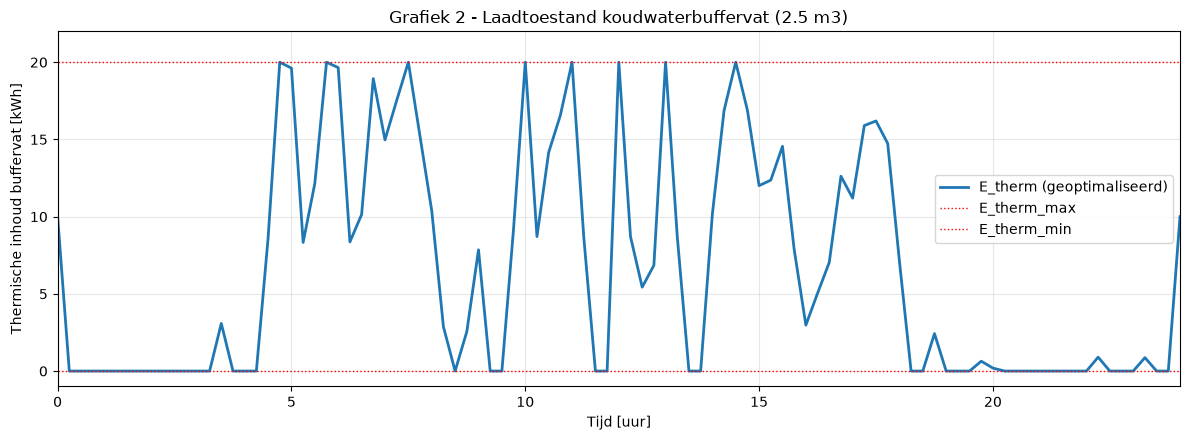

In [61]:
"""
Optimalisatie van chiller-aansturing met koudwaterbuffervat en capaciteitstarief (1 dag)
======================================================================================
"""

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =============================================================================
# 1. DATA INLEZEN EN VOORBEREIDEN
# =============================================================================

CSV_PATH = "plant1.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

# Eerste 24 uur = eerste 96 kwartieren (96 * 15 min = 24 h)
N_STEPS = 96
df = df.iloc[:N_STEPS].reset_index(drop=True)

dt = 0.25  # uur, tijdstap

# Prijs staat in EUR/MWh in plant1.csv -> omrekenen naar EUR/kWh
price = df["price"].values / 1000.0  # [EUR/kWh]
P_pv = df["pv_production"].values  # [kW]
P_inflex = df["inflex_load"].values  # [kW]
T_outdoor = df["outdoor_temperature"].values  # [degC]

time_h = np.arange(N_STEPS) * dt  # tijdas in uren

# =============================================================================
# 2. KOELVRAAGPROFIEL & PARAMETERS
# =============================================================================

Q_process_constant = 45.0  # kW thermisch (constante proceskoeling)
Q_demand = np.full(N_STEPS, Q_process_constant)

P_max_chiller = 250.0  # kW elektrisch

# Temperatuurafhankelijke COP
temp_points = [0, 5, 10, 15, 20, 25, 30]
cop_points = [4.5, 4.3, 4.0, 3.7, 3.4, 3.1, 2.8]
COP_t = np.interp(T_outdoor, temp_points, cop_points)

# Buffervat parameters (voor 2.5 m3)
V_buffer = 2.5  # m3
KWH_PER_M3 = 8.0  # kWh/m3
E_therm_max = V_buffer * KWH_PER_M3
E_therm_min = 0.0
eta_loss = 0.998

# =============================================================================
# 3. CAPACITEITSTARIEF PARAMETERS (Prorated naar 1 dag)
# =============================================================================
# Maandelijkse tarieven gedeeld door ~30 dagen voor de dagelijkse optimalisatie
DAYS_IN_MONTH = 30.0

# Abonnementskosten / minimum capaciteit (bijv. 2.5 kW minimum maandcapaciteit)
Access_power_kW = 2.5 
cost_access_daily = (Access_power_kW * 2.9975) / DAYS_IN_MONTH  # EUR / dag

# Tarief voor de maandelijkse piek (hier vertaald naar dagelijks equivalent)
tariff_peak_daily = 4.227 / DAYS_IN_MONTH  # EUR per kW piek per dag

# Tarief voor overschrijding (indien van toepassing)
tariff_exceed_daily = 4.496 / DAYS_IN_MONTH  # EUR per kW overschrijding per dag

print(f"Capaciteitstarief ingesteld (dagelijks equivalent):")
print(f"  Piek tarief: {tariff_peak_daily:.4f} EUR/kW/dag")
print(f"  Access power: {Access_power_kW} kW")

# =============================================================================
# 4. OPTIMALISATIEFUNCTIE MET CAPACITEITSTARIEF
# =============================================================================


def solve_chiller_schedule_with_capacity_tariff(E_therm_max):
  E_therm_0 = 0.5 * E_therm_max

  P_chiller = cp.Variable(N_STEPS, nonneg=True)
  P_grid_import = cp.Variable(N_STEPS, nonneg=True)
  P_grid_export = cp.Variable(N_STEPS, nonneg=True)
  E_therm = cp.Variable(N_STEPS + 1)

  # Hulpvariabele voor de maximale netafname (piek) van deze dag
  P_peak = cp.Variable(nonneg=True)

  Q_chiller = cp.multiply(COP_t, P_chiller)

  constraints = [
      P_chiller <= P_max_chiller,
      E_therm[0] == E_therm_0,
      E_therm >= E_therm_min,
      E_therm <= E_therm_max,
      E_therm[N_STEPS] == E_therm_0,
      P_pv + P_grid_import == P_chiller + P_inflex + P_grid_export,
      # Zorg dat P_peak groter is dan of gelijk aan elke netafname op elk tijdstip
      *[P_peak >= P_grid_import[t] for t in range(N_STEPS)],
  ]

  for t in range(N_STEPS):
    constraints += [
        E_therm[t + 1]
        == eta_loss * E_therm[t] + (Q_chiller[t] - Q_demand[t]) * dt
    ]

  # Doelfunctie: Energie-inkoopkosten (inkoop - verkoop) + Capaciteitstarief gebaseerd op P_peak
  energy_cost = cp.sum(cp.multiply(P_grid_import - P_grid_export, price) * dt)
  capacity_cost = P_peak * tariff_peak_daily

  objective = cp.Minimize(energy_cost + capacity_cost)
  problem = cp.Problem(objective, constraints)
  cost_opt = problem.solve(solver=cp.HIGHS)

  return {
      "status": problem.status,
      "cost": cost_opt,
      "P_peak": P_peak.value,
      "P_chiller": P_chiller.value,
      "P_grid_import": P_grid_import.value,
      "P_grid_export": P_grid_export.value,
      "E_therm": E_therm.value,
  }


# Voer optimalisatie uit voor het buffervat van 2.5 m3 (20 kWh)
res = solve_chiller_schedule_with_capacity_tariff(E_therm_max=E_therm_max)

print(f"\nOptimalisatie status: {res['status']}")
print(f"Totale kosten (inclusief capaciteitstarief): {res['cost']:.2f} EUR")
print(f"Maximale netafname piek vandaag: {res['P_peak']:.2f} kW")

# =============================================================================
# 5. VISUALISATIE
# =============================================================================

# =============================================================================
# 5. VISUALISATIE
# =============================================================================

# --- Grafiek 0: Constante koelvraagprofiel ---
fig0, ax0 = plt.subplots(figsize=(12, 4))
ax0.plot(
    time_h,
    Q_demand,
    color="tab:blue",
    linewidth=2,
    label="Q_demand (Constante proceskoeling)",
)
ax0.set_xlabel("Tijd [uur]")
ax0.set_ylabel("Koelvermogen [kW]")
ax0.set_xlim(0, 24)
ax0.set_title("Grafiek 0 - Constante koelvraagprofiel (gebaseerd op meetwaarde)")
ax0.legend(loc="upper left")
ax0.grid(alpha=0.3)
fig0.tight_layout()

# --- Grafiek 1: Elektrisch vermogen + prijs ---
fig1, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(
    time_h,
    res["P_chiller"],
    label="P_chiller (geoptimaliseerd)",
    color="tab:blue",
    linewidth=2,
)
ax1.plot(time_h, P_pv, label="P_PV", color="tab:orange", linewidth=1.5)
ax1.plot(
    time_h,
    res["P_grid_import"],
    label="P_grid_import",
    color="tab:green",
    linewidth=1.5,
)
ax1.plot(
    time_h,
    res["P_grid_export"],
    label="P_grid_export",
    color="tab:red",
    linewidth=1.5,
    linestyle="--",
)
ax1.set_xlabel("Tijd [uur]")
ax1.set_ylabel("Elektrisch vermogen [kW]")
ax1.set_xlim(0, 24)
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")

ax1b = ax1.twinx()
ax1b.step(
    time_h,
    price,
    where="post",
    color="black",
    linewidth=1.2,
    alpha=0.6,
    label="Elektriciteitsprijs",
)
ax1b.set_ylabel("Elektriciteitsprijs [EUR/kWh]")
ax1b.legend(loc="upper right")
ax1.set_title(
    f"Grafiek 1 - Elektrisch vermogen en prijs (buffervat {V_buffer} m3 / {E_therm_max:.0f} kWh)"
)
fig1.tight_layout()

# --- Grafiek 2: Laadtoestand buffervat ---
fig2, ax2 = plt.subplots(figsize=(12, 4.5))
time_h_full = np.arange(N_STEPS + 1) * dt
ax2.plot(
    time_h_full,
    res["E_therm"],
    label="E_therm (geoptimaliseerd)",
    color="tab:blue",
    linewidth=2,
)
ax2.axhline(
    E_therm_max,
    color="red",
    linestyle=":",
    linewidth=1,
    label="E_therm_max",
)
ax2.axhline(
    E_therm_min, color="red", linestyle=":", linewidth=1, label="E_therm_min"
)
ax2.set_xlabel("Tijd [uur]")
ax2.set_ylabel("Thermische inhoud buffervat [kWh]")
ax2.set_xlim(0, 24)
ax2.set_ylim(-1, E_therm_max + 2)
ax2.grid(alpha=0.3)
ax2.legend(loc="best")
ax2.set_title(f"Grafiek 2 - Laadtoestand koudwaterbuffervat ({V_buffer} m3)")
fig2.tight_layout()

plt.show()

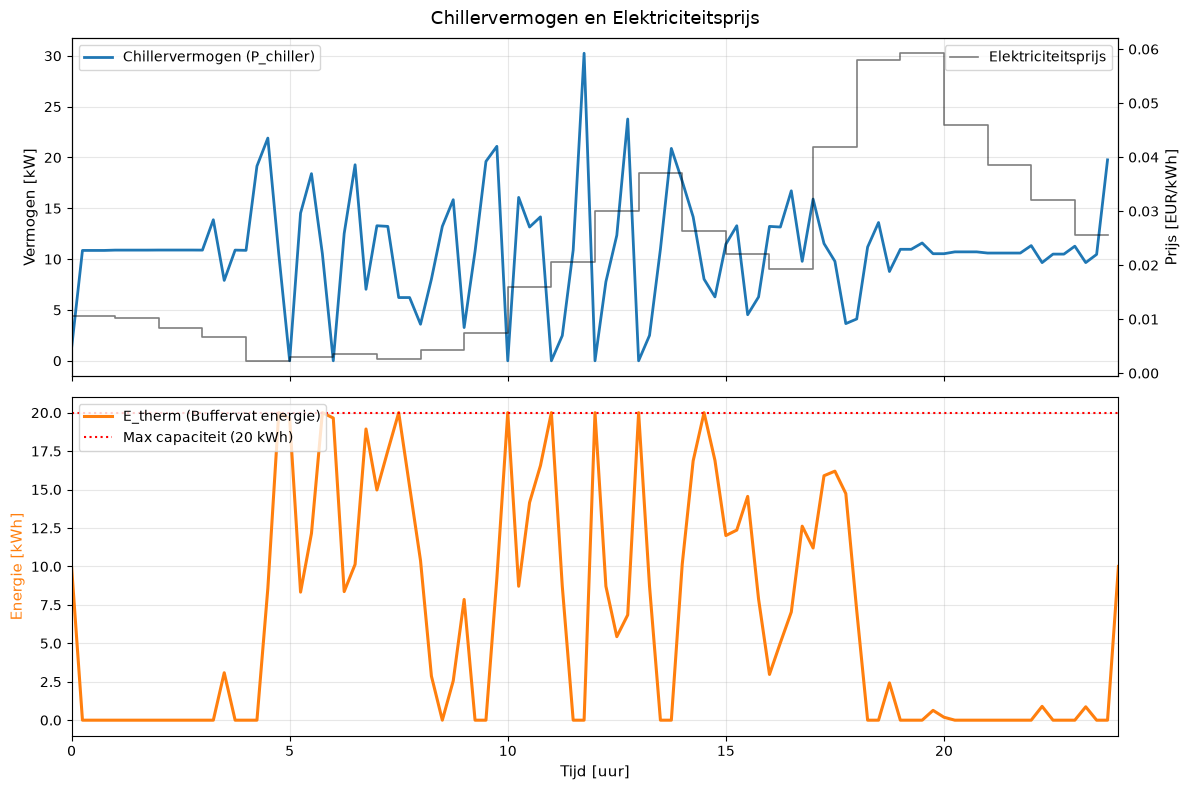

In [62]:
# =============================================================================
# 5. VISUALISATIE
# =============================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Subplot 1: Chillervermogen & Elektriciteitsprijs
ax1.plot(
    time_h,
    res["P_chiller"],
    color="tab:blue",
    linewidth=2,
    label="Chillervermogen (P_chiller)",
)
ax1.set_ylabel("Vermogen [kW]", fontsize=11)
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")
ax1.set_title(
    "Chillervermogen en Elektriciteitsprijs",
    fontsize=13,
    pad=10,
)

ax1b = ax1.twinx()
ax1b.step(
    time_h,
    price,
    where="post",
    color="black",
    linewidth=1.2,
    alpha=0.5,
    label="Elektriciteitsprijs",
)
ax1b.set_ylabel("Prijs [EUR/kWh]", color="black", fontsize=11)
ax1b.tick_params(axis="y", labelcolor="black")
ax1b.legend(loc="upper right")

# Subplot 2: Buffervat (E_therm)
time_h_full = np.arange(N_STEPS + 1) * dt
ax2.plot(
    time_h_full,
    res["E_therm"],
    color="tab:orange",
    linewidth=2.2,
    label="E_therm (Buffervat energie)",
)
ax2.axhline(
    E_therm_max, color="red", linestyle=":", label=f"Max capaciteit ({E_therm_max:.0f} kWh)"
)
ax2.set_xlabel("Tijd [uur]", fontsize=11)
ax2.set_ylabel("Energie [kWh]", color="tab:orange", fontsize=11)
ax2.set_xlim(0, 24)
ax2.grid(alpha=0.3)
ax2.legend(loc="upper left")

fig.tight_layout()
plt.show()